In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# S01 — Position, angle, and motion are different objects

Read the matching lesson before running. Predictions first; source facts, manufactured controls and interpretations are labeled separately. This is not a sports performance benchmark.

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
from dataclasses import asdict
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').exists())
sys.path.insert(0, str(ROOT / 'src'))
from shape_lab import sports_v8 as sport
from shape_lab.persistence import finite_bottleneck
spl, profiles = sport.load_sports(ROOT)
frames = np.array([r['frame'] for r in spl['records']])
times = sport.frame_times(frames, spl['sampling_rate'])
ball = sport.to_metres([r['ball'] for r in spl['records']], spl['xyz_unit'])
report_dir = ROOT / 'reports/v8/sports'
report_dir.mkdir(parents=True, exist_ok=True)
def save_report(stage, result):
    # Reports contain ordinary finite values; absent values are recorded explicitly.
    (report_dir / f'{stage}.json').write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Data:', len(frames), 'selected frames from one shot;', len(profiles), 'profiles from', profiles.player_id.nunique(), 'players')


Data: 12 selected frames from one shot; 12 profiles from 8 players


## A known angle before estimated coordinates

In [3]:
a=np.array([[1.,0,0]]); b=np.zeros((1,3)); c=np.array([[0.,1,0]])
assert sport.joint_angles(a,b,c)[0] == 90
assert np.allclose(sport.joint_angles(a+20,b+20,c+20), [90])
print('Right-angle and translation checks passed.')


Right-angle and translation checks passed.


## Unsigned estimated landmark angles

,frame,ideal_time_s,unsigned_angle_deg
0,0,0.000000,109.486679
1,1,0.016667,109.408256
2,90,1.500000,89.292292
3,110,1.833333,167.108152
4,115,1.916667,165.841515
5,120,2.000000,165.720598
6,125,2.083333,165.412675
7,130,2.166667,163.927183
8,135,2.250000,163.007486
9,140,2.333333,163.087082


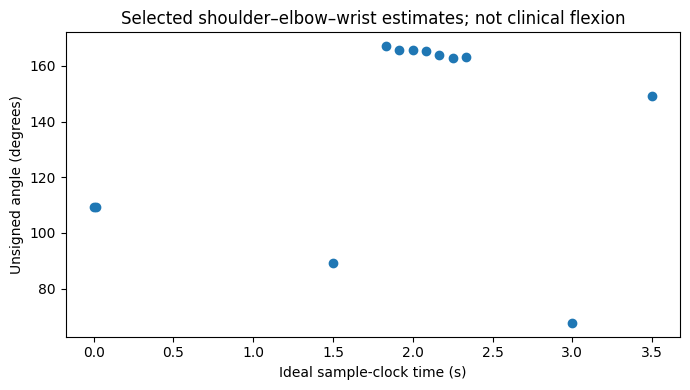

In [4]:
shoulder, elbow, wrist = [sport.to_metres([r[k] for r in spl['records']], 'ft') for k in ['right_shoulder','right_elbow','right_wrist']]
angles=sport.joint_angles(shoulder,elbow,wrist)
display(pd.DataFrame({'frame':frames, 'ideal_time_s':times, 'unsigned_angle_deg':angles}))
fig, ax = plt.subplots(figsize=(7,4)); ax.scatter(times, angles)
ax.set(xlabel='Ideal sample-clock time (s)', ylabel='Unsigned angle (degrees)', title='Selected shoulder–elbow–wrist estimates; not clinical flexion')
fig.tight_layout(); plt.show()


## Do not assign adjacent table rows adjacent frame times

In [5]:
v1, ok1=sport.interval_velocities(frames,ball,60,max_gap_frames=1)
v5, ok5=sport.interval_velocities(frames,ball,60,max_gap_frames=5)
table=pd.DataFrame({'start_frame':frames[:-1], 'end_frame':frames[1:], 'duration_s':np.diff(times), 'accepted_max_gap_5':ok5, 'secant_magnitude_m_s':np.linalg.norm(v5,axis=1)})
display(table)
assert ok1.sum() == 1
assert ok5.sum() == 7
save_report('S01',{'angles_deg':angles.tolist(),'strict_intervals':int(ok1.sum()),'five_frame_intervals':int(ok5.sum()),'total_intervals':len(ok5),'measurement_accuracy_validated':False})


,start_frame,end_frame,duration_s,accepted_max_gap_5,secant_magnitude_m_s
0,0,1,0.016667,True,0.309843
1,1,90,1.483333,False,NaN
2,90,110,0.333333,False,NaN
3,110,115,0.083333,True,5.614814
4,115,120,0.083333,True,4.873724
5,120,125,0.083333,True,4.833794
6,125,130,0.083333,True,4.583071
7,130,135,0.083333,True,4.089036
8,135,140,0.083333,True,4.051061
9,140,180,0.666667,False,NaN


## Independent explanation
State the observation unit, assumptions, units, one result and one unsupported conclusion. Then work the separate learner notebook without the answer notebook open.